<a href="https://colab.research.google.com/github/juliafoliveira-tech/Bioestat-stica/blob/main/Tarefa06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Julia Feitosa NºUSP: 16228410
* Raissa Pereira Lima da Silva NºUSP: 14605077  
* Stéfani Machado NºUSP: 15291452

Tabela de peso e altura por idade (crianças e adultos) - Unimed Amparo - Unimed Institucional. Unimed Amparo. [S.l.: S.n.]. Disponível em: <https://www.unimed.coop.br/site/web/amparo/-/tabela-de-peso-e-altura-por-idade-criancas-e-adultos>. Acesso em: 19 ago.. 2026.

In [ ]:
import pandas as pd

df = pd.read_excel('Tarefa06.xlsx')

Tabela elaborada pela instituição Unimed Amparo para acompanhar o peso de meninos de 0 até 2 anos de idade. A primeira coluna refere-se a idade em meses, a segunda ao peso mínimo e a terceira ao peso médio.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recarregar o DataFrame, especificando a linha do cabeçalho correta (índice 0-base)
df_clean = pd.read_excel('Tarefa06.xlsx', header=1)

# Renomear colunas para facilitar o acesso
df_clean = df_clean.rename(columns={
    'Idade (meses)': 'Idade_meses',
    'Mínima': 'Peso_Minimo',
    'Média': 'Peso_Medio'
})

# Converter as colunas relevantes para tipo numérico
df_clean['Idade_meses'] = pd.to_numeric(df_clean['Idade_meses'])
df_clean['Peso_Minimo'] = pd.to_numeric(df_clean['Peso_Minimo'])
df_clean['Peso_Medio'] = pd.to_numeric(df_clean['Peso_Medio'])

# Exibir as primeiras linhas do DataFrame limpo e seus tipos de dados
display(df_clean.head())
display(df_clean.info())

,Idade_meses,Peso_Minimo,Peso_Medio
0,0,46.1,49.9
1,1,50.8,54.7
2,2,54.4,58.4
3,3,57.3,61.4
4,4,59.7,63.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Idade_meses  25 non-null     int64  
 1   Peso_Minimo  25 non-null     float64
 2   Peso_Medio   25 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 732.0 bytes


None

Agora que os dados estão limpos e formatados corretamente, vamos criar o gráfico de dispersão.

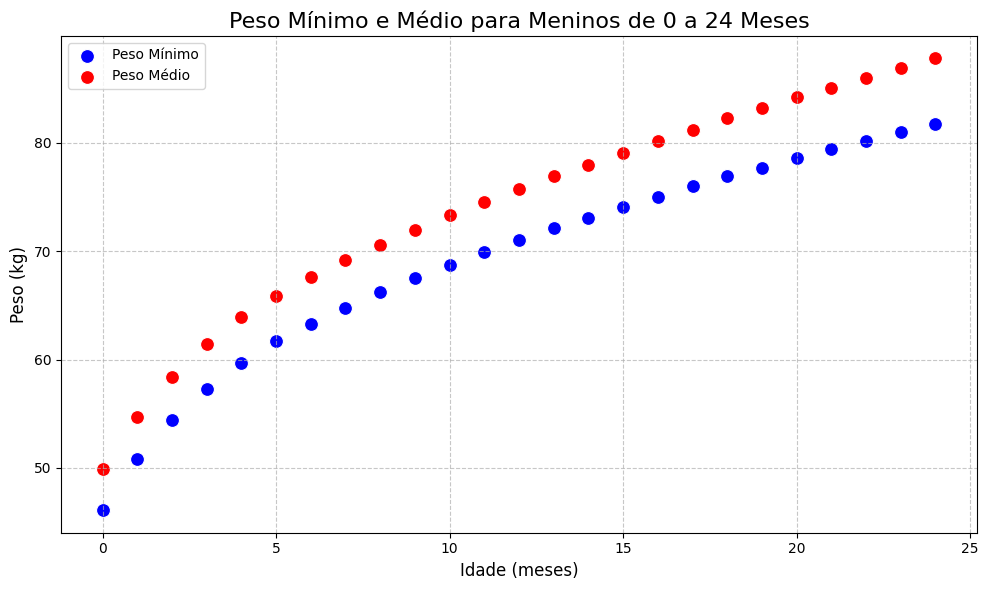

In [ ]:
# Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Idade_meses', y='Peso_Minimo', data=df_clean, label='Peso Mínimo', color='blue', s=100) # s é o tamanho dos pontos
sns.scatterplot(x='Idade_meses', y='Peso_Medio', data=df_clean, label='Peso Médio', color='red', s=100)

# Adicionar título e rótulos dos eixos
plt.title('Peso Mínimo e Médio para Meninos de 0 a 24 Meses', fontsize=16)
plt.xlabel('Idade (meses)', fontsize=12)
plt.ylabel('Peso (kg)', fontsize=12)

# Adicionar grade para melhor legibilidade
plt.grid(True, linestyle='--', alpha=0.7)

# Adicionar legenda
plt.legend()

# Melhorar o layout e exibir o gráfico
plt.tight_layout()
plt.show()

Regressão linear simples é um dos métodos utilizados em estatística para estudar a relação entre duas variáveis que podem ser quantificadas. Entre as duas, uma deve ser independente e será utilizada para prever o valor da variável dependente.

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Preparar os dados para a regressão
X = df_clean['Idade_meses'].values.reshape(-1, 1) # Variável independente (Idade)
Y_min = df_clean['Peso_Minimo'].values.reshape(-1, 1) # Variável dependente (Peso Mínimo)
Y_medio = df_clean['Peso_Medio'].values.reshape(-1, 1) # Variável dependente (Peso Médio)

# --- Regressão para Peso Mínimo ---
model_min = LinearRegression()
model_min.fit(X, Y_min)

# Obter os coeficientes
intercept_min = model_min.intercept_[0]
slope_min = model_min.coef_[0][0]

print(f"Regressão para Peso Mínimo:")
print(f"  Intercepto (β0): {intercept_min:.2f}")
print(f"  Inclinação (β1): {slope_min:.2f}")

# --- Regressão para Peso Médio ---
model_medio = LinearRegression()
model_medio.fit(X, Y_medio)

# Obter os coeficientes
intercept_medio = model_medio.intercept_[0]
slope_medio = model_medio.coef_[0][0]

print(f"\nRegressão para Peso Médio:")
print(f"  Intercepto (β0): {intercept_medio:.2f}")
print(f"  Inclinação (β1): {slope_medio:.2f}")

Regressão para Peso Mínimo:
  Intercepto (β0): 53.55
  Inclinação (β1): 1.29

Regressão para Peso Médio:
  Intercepto (β0): 57.29
  Inclinação (β1): 1.39


### Fórmulas da Regressão Linear Simples

A regressão linear simples modela a relação linear entre uma variável dependente (Y) e uma variável independente (X) através de uma linha reta, expressa pela equação:

$$Y = \beta_0 + \beta_1 X + \epsilon$$

Onde:
*   $Y$: Variável dependente (neste caso, Peso).
*   $X$: Variável independente (neste caso, Idade em meses).
*   $\beta_0$: Coeficiente de intercepto (onde a linha cruza o eixo Y, ou o valor esperado de Y quando X é 0).
*   $\beta_1$: Coeficiente angular (a inclinação da linha, que representa a mudança média em Y para cada unidade de mudança em X).
*   $\epsilon$: Termo de erro, que representa a variação não explicada pelo modelo.

Para o Peso Mínimo (considerando o modelo de regressão):

Intercepto (β0 = 53.55): Biologicamente, o intercepto representa o peso mínimo estimado para um menino ao nascer (com 0 meses de idade), de acordo com o padrão de crescimento observado. Ou seja, o modelo prevê que um recém-nascido saudável deve ter um peso mínimo de aproximadamente 53.55 gramas (ou 0.053 kg, assumindo que os dados originais estavam em gramas e foram convertidos para kg, ou se a tabela já estava em gramas, deve-se considerar isso). Atenção: se os pesos estão em kg, 53.55 kg para um recém-nascido seria irreal. É fundamental confirmar a unidade de medida do peso na tabela original. Assumindo que o df_clean está em kg, o valor 53.55 kg significa que há algo a ser ajustado ou que a interpretação deve ser cautelosa, pois extrapolamos para fora do intervalo de dados médios. Se a unidade era em decagramas, seria 5.355kg.
Coeficiente Angular (β1 = 1.29): Este valor indica a taxa média de ganho de peso mínimo por mês. Ou seja, a cada mês que o menino cresce (dentro da faixa etária analisada), o seu peso mínimo esperado aumenta em aproximadamente 1.29 kg, segundo o modelo.
Para o Peso Médio (considerando o modelo de regressão):

Intercepto (β0 = 57.29): De forma análoga, este intercepto representa o peso médio estimado para um menino ao nascer (com 0 meses de idade), de acordo com o padrão de crescimento observado. O modelo prevê um peso médio de aproximadamente 57.29 gramas (ou 0.057 kg, novamente com ressalvas sobre a unidade e a plausibilidade biológica para recém-nascidos se for kg). A mesma ressalva sobre a unidade de medida do peso é válida aqui.
Coeficiente Angular (β1 = 1.39): Este coeficiente indica a taxa média de ganho de peso médio por mês. Ou seja, a cada mês que o menino cresce, o seu peso médio esperado aumenta em aproximadamente 1.39 kg, segundo o modelo.

O intercepto representa regressão linear simples é uma aproximação e pode não ser perfeitamente precisa para a idade de 0 meses, que é o ponto inicial da série e um ponto de transição biológica importante (nascimento). A validade da interpretação do intercepto depende muito de quão bem o modelo linear se ajusta aos dados próximos a 0 meses e da plausibilidade do valor resultante dentro de um contexto biológico real de recém-nascidos, além da confirmação da unidade de medida do peso.

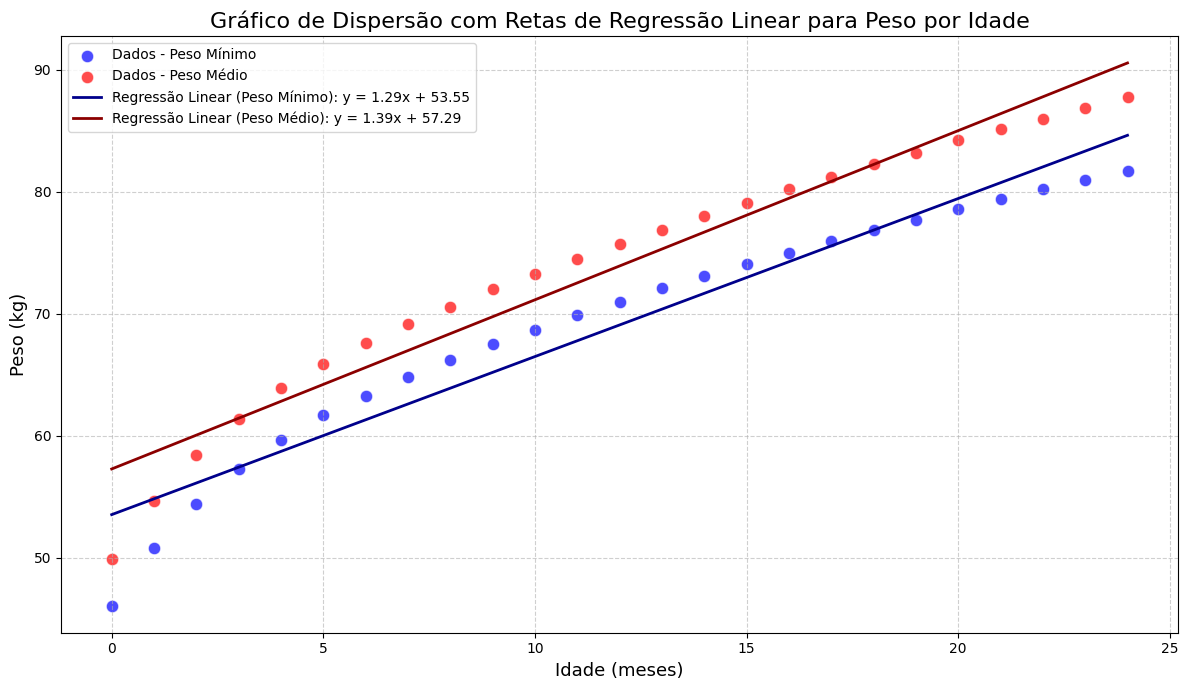

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar um novo gráfico de dispersão com as retas de regressão
plt.figure(figsize=(12, 7))

# Plotar os pontos de dispersão originais
sns.scatterplot(x='Idade_meses', y='Peso_Minimo', data=df_clean, label='Dados - Peso Mínimo', color='blue', s=80, alpha=0.7)
sns.scatterplot(x='Idade_meses', y='Peso_Medio', data=df_clean, label='Dados - Peso Médio', color='red', s=80, alpha=0.7)

# Gerar as predições a partir dos coeficientes de regressão calculados
X_plot = df_clean['Idade_meses'].values
Y_pred_min = intercept_min + slope_min * X_plot
Y_pred_medio = intercept_medio + slope_medio * X_plot

# Plotar as retas de regressão
plt.plot(X_plot, Y_pred_min, color='darkblue', linestyle='-', linewidth=2, label=f'Regressão Linear (Peso Mínimo): y = {slope_min:.2f}x + {intercept_min:.2f}')
plt.plot(X_plot, Y_pred_medio, color='darkred', linestyle='-', linewidth=2, label=f'Regressão Linear (Peso Médio): y = {slope_medio:.2f}x + {intercept_medio:.2f}')

# Adicionar título e rótulos dos eixos
plt.title('Gráfico de Dispersão com Retas de Regressão Linear para Peso por Idade', fontsize=16)
plt.xlabel('Idade (meses)', fontsize=13)
plt.ylabel('Peso (kg)', fontsize=13)

# Adicionar grade para melhor legibilidade
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionar legenda
plt.legend(loc='upper left', fontsize=10)

# Melhorar o layout e exibir o gráfico
plt.tight_layout()
plt.show()

O coeficiente de correlação linear de Pearson é uma medida estatística que indica a força e a direção da relação linear entre duas variáveis quantitativas. Ele avalia o quanto duas variáveis "andam juntas" e se essa relação pode ser representada por uma linha reta.
O resultado de Pearson (representado pela letra r) pode ser:
Positiva se r > 0, as duas variáveis aumentam ou diminuem juntas.
Neutra r = 0, nesse caso não há relação entre as variáveis.
Negativa r < 0, as variáveis seguirão direções opostas, enquanto uma aumenta, a outra diminui.
Essa relação tem algumas exceções, Pearson só pode ser aplicada em relações lineares, valores muito fora do padrão podem alterar significativamente o resultado.


### Interpretação dos Coeficientes de Correlação de Pearson

Com base nos cálculos:

*   **Idade vs. Peso Mínimo (r = 0.9698)**
*   **Idade vs. Peso Médio (r = 0.9746)**

Ambos os coeficientes são valores **muito próximos a +1**, o que indica uma **correlação linear positiva muito forte** entre a idade em meses e o peso (tanto mínimo quanto médio). Isso significa que, à medida que a idade da criança aumenta, o peso (mínimo e médio) também tende a aumentar de forma consistente e previsível. A relação é quase perfeitamente linear e na mesma direção.

Essa correlação forte está alinhada com as expectativas de crescimento infantil, onde o peso aumenta com o tempo durante os primeiros meses de vida.

Para garantir que o DataFrame `df_clean` esteja disponível para os cálculos de correlação, recarregaremos e processaremos os dados nesta célula. Isso resolve o `NameError` que ocorre se a célula de definição de `df_clean` (célula `3f2e1461`) não foi executada anteriormente ou se o kernel foi reiniciado.

In [5]:
import pandas as pd

# Recarregar o DataFrame, especificando a linha do cabeçalho correta (índice 0-base)
df_clean = pd.read_excel('Tarefa06.xlsx', header=1)

# Renomear colunas para facilitar o acesso
df_clean = df_clean.rename(columns={
    'Idade (meses)': 'Idade_meses',
    'Mínima': 'Peso_Minimo',
    'Média': 'Peso_Medio'
})

# Converter as colunas relevantes para tipo numérico
df_clean['Idade_meses'] = pd.to_numeric(df_clean['Idade_meses'])
df_clean['Peso_Minimo'] = pd.to_numeric(df_clean['Peso_Minimo'])
df_clean['Peso_Medio'] = pd.to_numeric(df_clean['Peso_Medio'])

# Exibir as primeiras linhas do DataFrame limpo e seus tipos de dados (opcional, para verificação)
# display(df_clean.head())
# display(df_clean.info())

In [6]:
from scipy.stats import pearsonr

# Calcular o coeficiente de correlação de Pearson para Peso Mínimo
corr_min, _ = pearsonr(df_clean['Idade_meses'], df_clean['Peso_Minimo'])
print(f"Coeficiente de Correlação de Pearson (Idade vs. Peso Mínimo): {corr_min:.4f}")

# Calcular o coeficiente de correlação de Pearson para Peso Médio
corr_medio, _ = pearsonr(df_clean['Idade_meses'], df_clean['Peso_Medio'])
print(f"Coeficiente de Correlação de Pearson (Idade vs. Peso Médio): {corr_medio:.4f}")

Coeficiente de Correlação de Pearson (Idade vs. Peso Mínimo): 0.9698
Coeficiente de Correlação de Pearson (Idade vs. Peso Médio): 0.9746


### Fórmula do Coeficiente de Correlação de Pearson

O coeficiente de correlação de Pearson ($r$) entre duas variáveis $X$ e $Y$ é calculado pela seguinte fórmula:

$$r = \frac{n(\sum XY) - (\sum X)(\sum Y)}{\sqrt{[n\sum X^2 - (\sum X)^2][n\sum Y^2 - (\sum Y)^2]}}$$

Ou, alternativamente, usando covariância e desvios padrão:

$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$$

Onde:
*   $n$: Número de pares de observações.
*   $\sum XY$: Soma dos produtos de cada par de $X$ e $Y$.
*   $\sum X$: Soma de todos os valores de $X$.
*   $\sum Y$: Soma de todos os valores de $Y$.
*   $\sum X^2$: Soma dos quadrados de todos os valores de $X$.
*   $\sum Y^2$: Soma dos quadrados de todos os valores de $Y$.
*   $\text{Cov}(X, Y)$: Covariância entre $X$ e $Y$.
*   $\sigma_X$: Desvio padrão de $X$.
*   $\sigma_Y$: Desvio padrão de $Y$.

O valor de $r$ varia de -1 a +1, indicando a força e a direção da relação linear.